In [9]:
CSV_PATH = "../data/hospital/polluted/aggregationofpollution.csv"
OUTPUT_DIR = "./results/"
SIM_RANDOM_SEED = 42

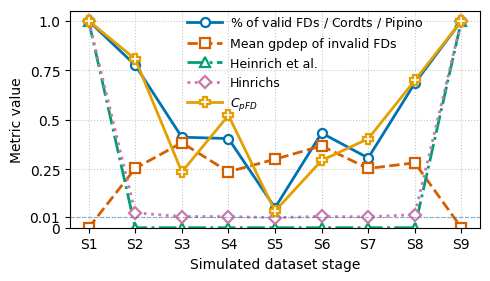

In [11]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================

N_RANDOM_CANDIDATES = 250
N_STAGES_TO_PLOT = 10

# Set to "hospital" if you only want one dataset.
# Set to None to simulate each dataset separately.
EXAMPLE_DATASET = None

# Allows a clean S1 stage where no FD is violated.
INCLUDE_CLEAN_STAGE = True

# If gpdep weights are all zero or missing, use equal weights.
FALLBACK_TO_EQUAL_WEIGHTS = True
df = pd.read_csv(CSV_PATH)

# ============================================================
# Helpers
# ============================================================

def parse_fd_sides(fd: str):
    """
    Parses strings like:
        Address1 -> Address2
        A, B -> C, D
    Returns:
        lhs_attrs, rhs_attrs
    """
    fd = str(fd)

    if "->" not in fd:
        return [], []

    lhs, rhs = fd.split("->", 1)

    lhs_attrs = [
        a.strip()
        for a in re.split(r"\s*,\s*", lhs)
        if a.strip()
    ]

    rhs_attrs = [
        a.strip()
        for a in re.split(r"\s*,\s*", rhs)
        if a.strip()
    ]

    return lhs_attrs, rhs_attrs


def safe_weighted_average(values: pd.Series, weights: pd.Series) -> float:
    tmp = pd.concat([values, weights], axis=1).dropna()
    if tmp.empty:
        return np.nan

    v = tmp.iloc[:, 0].astype(float).to_numpy()
    w = tmp.iloc[:, 1].astype(float).clip(lower=0).to_numpy()

    if np.isclose(w.sum(), 0):
        return np.nan

    return float(np.average(v, weights=w))


def safe_weighted_binary_score(binary_values: pd.Series, weights: pd.Series) -> float:
    tmp = pd.concat([binary_values, weights], axis=1).dropna()
    if tmp.empty:
        return np.nan

    b = tmp.iloc[:, 0].astype(float).to_numpy()
    w = tmp.iloc[:, 1].astype(float).clip(lower=0).to_numpy()

    if np.isclose(w.sum(), 0):
        return np.nan

    return float(np.sum(w * b) / np.sum(w))


def sanitize_filename(text: str) -> str:
    text = str(text)
    text = re.sub(r"[^\w\-_. ]", "_", text)
    text = re.sub(r"\s+", "_", text)
    return text


def nice_metric_name(metric: str) -> str:
    rename = {
        "qw_lin": r"$C_{pFD}$",
        "qw_bin": r"$C_{pFD}$",

        "fd_hold_pct": "$\%$ of valid FDs / Cordts / Pipino",
        "fd_hold_pct_gpdep": "gpdep-weighted FD hold share",
        "fd_violated_pct": "Violated FD share",
        "fd_violated_pct_gpdep": "gpdep-weighted violated FD share",

        "cordts_pipino": "Cordts/Pipino",
        "cordts_pipino_gpdep": "Cordts/Pipino, gpdep-weighted",

        "heinrich_product_exact": "Heinrich et al.",
        "heinrich_product_gpdep": "Heinrich et al., gpdep-weighted",

        "hinrichs_exact": "Hinrichs",
        "hinrichs_gpdep": "Hinrichs, gpdep-weighted",

        "gpdep_mean_violated": "Mean gpdep of invalid FDs",
        "gpdep_sum_violated": "Sum gpdep of violated FDs",
    }
    return rename.get(metric, metric)


def select_most_different_by_value(df, n=10, value_col="qw_bin"):
    """
    Greedily selects rows that are far apart in value_col.
    Useful for making a small example plot with visibly different stages.
    """
    df = df.dropna(subset=[value_col]).sort_values(value_col).reset_index(drop=True)

    if len(df) <= n:
        return df.copy()

    values = df[value_col].to_numpy()

    selected = [0, len(df) - 1]

    while len(selected) < n:
        remaining = [i for i in range(len(df)) if i not in selected]

        best_i = None
        best_dist = -1

        for i in remaining:
            d = min(abs(values[i] - values[j]) for j in selected)
            if d > best_dist:
                best_dist = d
                best_i = i

        selected.append(best_i)

    selected = sorted(selected, key=lambda i: values[i], reverse=True)
    return df.iloc[selected].reset_index(drop=True).copy()


# ============================================================
# Build FD catalog
# ============================================================

df_sim_base = df.copy()

if EXAMPLE_DATASET is not None:
    df_sim_base = df_sim_base[df_sim_base["dataset_name"] == EXAMPLE_DATASET].copy()

fd_catalog = (
    df_sim_base
    .groupby(["dataset_name", "fd"], dropna=False, as_index=False)
    .agg(
        gpdep=("gpdep", "mean"),
    )
)

parsed = fd_catalog["fd"].apply(parse_fd_sides)
fd_catalog["lhs_attributes"] = parsed.apply(lambda x: x[0])
fd_catalog["rhs_attributes"] = parsed.apply(lambda x: x[1])

fd_catalog = fd_catalog[fd_catalog["rhs_attributes"].apply(len) > 0].copy()

if fd_catalog.empty:
    raise ValueError("No usable FDs found. Check that the fd column contains strings like 'A -> B'.")


# ============================================================
# Simulate one stage
# ============================================================

def rescale_to_max_one(series: pd.Series) -> pd.Series:
    max_val = series.max(skipna=True)

    if pd.isna(max_val) or np.isclose(max_val, 0):
        return series

    return series / max_val


def pick_closest_unused(df, target, value_col, used_indices):
    candidates = df.loc[~df.index.isin(used_indices)].copy()

    if candidates.empty:
        return None

    candidates["_target_distance"] = (candidates[value_col] - target).abs()

    # Prefer candidates close to the target.
    sort_cols = ["_target_distance"]

    if "n_violated_fds" in candidates.columns:
        sort_cols.append("n_violated_fds")

    selected_idx = candidates.sort_values(sort_cols).index[0]

    return selected_idx


def select_recovery_stages(
    df,
    n=11,
    quality_col="fd_hold_pct",
):
    """
    Creates a trajectory:
        clean -> degradation -> strongest degradation -> recovery -> clean

    The first and last stages are the best available point.
    If max(fd_hold_pct) is not 1.0, fd_hold_pct is rescaled so max becomes 1.0.
    """
    df = df.copy()

    if df.empty:
        return df

    # Rescale quality so the best available point is exactly 1.0.
    if not np.isclose(df[quality_col].max(skipna=True), 1.0):
        df[f"{quality_col}_raw"] = df[quality_col]
        df[quality_col] = rescale_to_max_one(df[quality_col])

    # Best and worst available points.
    best_idx = df[quality_col].idxmax()
    min_middle_quality = 0.05

    eligible_worst = df[df[quality_col] >= min_middle_quality]
    
    if not eligible_worst.empty and eligible_worst[quality_col].min() < df[quality_col].max():
        worst_idx = eligible_worst[quality_col].idxmin()
    else:
        worst_idx = df[quality_col].idxmin()

    best_quality = float(df.loc[best_idx, quality_col])
    worst_quality = float(df.loc[worst_idx, quality_col])

    if n <= 2:
        out = df.loc[[best_idx, best_idx]].copy()
        out["stage"] = [f"S{i}" for i in range(1, len(out) + 1)]
        return out

    left_count = n // 2
    right_count = n - left_count - 1

    noise_strength = 0.16
    rng = np.random.default_rng(SIM_RANDOM_SEED)
    
    left_targets = np.linspace(best_quality, worst_quality, left_count)
    right_targets = np.linspace(worst_quality, best_quality, right_count + 1)[1:]
    
    targets = list(left_targets) + list(right_targets)
    
    noisy_targets = []
    
    for i, target in enumerate(targets):
        is_first = i == 0
        is_last = i == len(targets) - 1
        is_middle = np.isclose(target, worst_quality)
    
        if is_first or is_last or is_middle:
            noisy_targets.append(target)
        else:
            # Distance from nearest endpoint: higher near the middle
            pos = i / (len(targets) - 1)
            middle_weight = np.sin(np.pi * pos)
    
            noise = rng.normal(
                loc=0.0,
                scale=noise_strength * middle_weight,
            )
    
            noisy_target = target + noise
            noisy_target = np.clip(noisy_target, worst_quality, best_quality)
    
            noisy_targets.append(float(noisy_target))
    
    targets = noisy_targets

    selected_indices = []
    used_indices = set()

    for pos, target in enumerate(targets):
        # Force first and last to be the clean/best point.
        if pos == 0 or pos == len(targets) - 1:
            selected_indices.append(best_idx)
            continue

        # Force the middle point to be the strongest degradation.
        if np.isclose(target, worst_quality):
            idx = worst_idx
        else:
            idx = pick_closest_unused(
                df=df,
                target=target,
                value_col=quality_col,
                used_indices=used_indices | {best_idx},
            )

        if idx is None:
            idx = pick_closest_unused(
                df=df,
                target=target,
                value_col=quality_col,
                used_indices=set(),
            )

        selected_indices.append(idx)

        if idx is not None:
            used_indices.add(idx)

    out = df.loc[selected_indices].copy().reset_index(drop=True)
    out["stage"] = [f"S{i}" for i in range(1, len(out) + 1)]

    return out
    
def select_anchored_stages(
    df,
    n=11,
    quality_col="fd_hold_pct",
    diversity_col="qw_bin",
):
    df = df.copy()

    # Rescale fd_hold_pct if no exact 1.0 exists
    if not np.isclose(df[quality_col].max(skipna=True), 1.0):
        df[f"{quality_col}_raw"] = df[quality_col]
        df[quality_col] = rescale_to_max_one(df[quality_col])

    # Best available point after possible rescaling
    best_idx = df[quality_col].idxmax()
    best_row = df.loc[[best_idx]].copy()

    # Candidate middle points: exclude best point if possible
    middle_pool = df.drop(index=best_idx).copy()

    if middle_pool.empty or n <= 2:
        out = pd.concat([best_row, best_row.copy()], ignore_index=True)
        out["stage"] = [f"S{i}" for i in range(1, len(out) + 1)]
        return out

    n_middle = max(0, n - 2)

    # Prefer visibly different middle points
    middle = select_most_different_by_value(
        middle_pool,
        n=n_middle,
        value_col=diversity_col,
    )

    # Sort middle from better to worse, so the story is:
    # clean -> degradation -> clean/reference again
    middle = middle.sort_values(
        [quality_col, diversity_col],
        ascending=[False, False],
    )

    # Anchor first and last at the best available point
    out = pd.concat(
        [
            best_row.copy(),
            middle,
            best_row.copy(),
        ],
        ignore_index=True,
    )

    out["stage"] = [f"S{i}" for i in range(1, len(out) + 1)]

    return out


def simulate_stage(fd_cat: pd.DataFrame, chosen_rhs_attributes, stage_id: str):
    chosen_rhs_attributes = set(chosen_rhs_attributes)

    out = {
        "stage": stage_id,
        "dataset_name": fd_cat["dataset_name"].iloc[0],
        "violated_rhs_attributes": ", ".join(sorted(chosen_rhs_attributes)),
        "n_violated_rhs_attributes": len(chosen_rhs_attributes),
        "n_fds": len(fd_cat),
    }

    schema_attributes = set()
    for attrs in fd_cat["lhs_attributes"]:
        schema_attributes.update(attrs)
    for attrs in fd_cat["rhs_attributes"]:
        schema_attributes.update(attrs)

    n_attributes = max(1, len(schema_attributes))

    violated = fd_cat["rhs_attributes"].apply(
        lambda rhs_attrs: bool(set(rhs_attrs) & chosen_rhs_attributes)
    )

    holds = (~violated).astype(int)
    strict_violation = violated.astype(int)

    weights = fd_cat["gpdep"].astype(float).fillna(0).clip(lower=0)

    weight_sum = weights.sum()
    if np.isclose(weight_sum, 0):
        norm_weights = pd.Series(1.0 / len(weights), index=weights.index)
    else:
        norm_weights = weights / weight_sum
        
    if FALLBACK_TO_EQUAL_WEIGHTS and np.isclose(weights.sum(), 0):
        weights = pd.Series(1.0, index=fd_cat.index)

    simulated_partial_value = holds.astype(float)

    out["n_violated_fds"] = int(strict_violation.sum())
    out["fd_violated_pct"] = float(strict_violation.mean())
    out["fd_hold_pct"] = float(holds.mean())

    out["fd_hold_weighted"] = safe_weighted_binary_score(holds, weights)

    weighted_violation_share = float(np.sum(norm_weights * strict_violation))
    weighted_hold_share = float(np.sum(norm_weights * holds))

    out["cordts_pipino_gpdep"] = 1.0 - weighted_violation_share
    out["heinrich_product_gpdep"] = float(
        np.prod(1.0 - norm_weights * strict_violation)
    )
    out["hinrichs_gpdep_raw"] = float(
        1.0 / (1.0 + weighted_violation_share)
    )
    out["qw_lin"] = safe_weighted_average(simulated_partial_value, weights)
    out["qw_bin"] = safe_weighted_binary_score(holds, weights)

    # Related-work metrics
    out["heinrich_product_exact"] = (1 - strict_violation).prod()
    out["hinrichs_exact"] = 1.0 / (strict_violation.sum() + 1.0)
    out["cordts_pipino"] = max(0.0, 1.0 - strict_violation.sum() / len(fd_cat))
    
    if violated.any():
        out["gpdep_mean_violated"] = float(fd_cat.loc[violated, "gpdep"].mean())
    else:
        out["gpdep_mean_violated"] = 0.0

    violated_fds = fd_cat.loc[violated, "fd"].tolist()
    out["violated_fds"] = " | ".join(violated_fds)

    return out


# ============================================================
# Generate random candidate stages
# ============================================================

all_stage_rows = []

rng = np.random.default_rng(SIM_RANDOM_SEED)

for dataset_name, fd_cat in fd_catalog.groupby("dataset_name", dropna=False):
    fd_cat = fd_cat.reset_index(drop=True).copy()

    rhs_pool = sorted({
        attr
        for attrs in fd_cat["rhs_attributes"]
        for attr in attrs
    })

    if len(rhs_pool) == 0:
        continue

    seen = set()

    if INCLUDE_CLEAN_STAGE:
        chosen = tuple()
        seen.add(chosen)
        all_stage_rows.append(
            simulate_stage(fd_cat, chosen, stage_id="candidate_clean")
        )

    for i in range(N_RANDOM_CANDIDATES):
        k = int(rng.integers(1, len(rhs_pool) + 1))

        chosen = tuple(sorted(
            rng.choice(rhs_pool, size=k, replace=False).tolist()
        ))

        if chosen in seen:
            continue

        seen.add(chosen)

        all_stage_rows.append(
            simulate_stage(fd_cat, chosen, stage_id=f"candidate_{i + 1}")
        )

candidate_stage_df = pd.DataFrame(all_stage_rows)

candidate_stage_df.to_csv(
    os.path.join(OUTPUT_DIR, "simulated_stage_candidates.csv"),
    index=False
)


# ============================================================
# Select a small example of stages to plot
# ============================================================

selected_stage_rows = []

for dataset_name, g in candidate_stage_df.groupby("dataset_name", dropna=False):
    selected = select_recovery_stages(
        g,
        n=N_STAGES_TO_PLOT,
        quality_col="fd_hold_pct",
    )

    selected_stage_rows.append(selected)

simulated_stage_df = pd.concat(selected_stage_rows, ignore_index=True)

simulated_stage_df.to_csv(
    os.path.join(OUTPUT_DIR, "simulated_stage_metrics.csv"),
    index=False
)

# ============================================================
# Plot selected stages
# ============================================================

base_metric_cols = [
    "fd_hold_pct",
    "heinrich_product_exact",
#    "cordts_pipino",
    "hinrichs_exact",
    "qw_bin",
    #"cordts_pipino_gpdep",
    #"hinrichs_gpdep",
    #"heinrich_product_gpdep",
]

# Only include gpdep diagnostic if it changes.
if simulated_stage_df["gpdep_mean_violated"].nunique(dropna=True) > 1:
    base_metric_cols.insert(1,"gpdep_mean_violated")

# Only include Qw-lin separately if it differs from Qw-bin.
if not np.allclose(
    simulated_stage_df["qw_lin"],
    simulated_stage_df["qw_bin"],
    equal_nan=True,
):
    base_metric_cols.insert(0, "qw_lin")

Y_LOG_FLOOR = 1e-4   # plotted location for exact zeros
Y_SPLIT = 0.01        # boundary between log and linear region
Y_TOP = 1.05         # upper y-limit
Y_SPLIT_FRAC = 0.05   # bottom half of plot is reserved for [0, 0.1]


def piecewise_forward(y):
    y = np.asarray(y, dtype=float)
    y = np.clip(y, Y_LOG_FLOOR, Y_TOP)

    out = np.empty_like(y)

    bottom = y <= Y_SPLIT

    # Log-scaled bottom half: [Y_LOG_FLOOR, 0.1] -> [0, 0.5]
    out[bottom] = (
        Y_SPLIT_FRAC
        * (np.log10(y[bottom]) - np.log10(Y_LOG_FLOOR))
        / (np.log10(Y_SPLIT) - np.log10(Y_LOG_FLOOR))
    )

    # Linear-scaled top half: [0.1, 1.05] -> [0.5, 1]
    out[~bottom] = (
        Y_SPLIT_FRAC
        + (1 - Y_SPLIT_FRAC)
        * (y[~bottom] - Y_SPLIT)
        / (Y_TOP - Y_SPLIT)
    )

    return out


def piecewise_inverse(t):
    t = np.asarray(t, dtype=float)

    out = np.empty_like(t)

    bottom = t <= Y_SPLIT_FRAC

    out[bottom] = 10 ** (
        np.log10(Y_LOG_FLOOR)
        + t[bottom] / Y_SPLIT_FRAC
        * (np.log10(Y_SPLIT) - np.log10(Y_LOG_FLOOR))
    )

    out[~bottom] = (
        Y_SPLIT
        + (t[~bottom] - Y_SPLIT_FRAC)
        / (1 - Y_SPLIT_FRAC)
        * (Y_TOP - Y_SPLIT)
    )

    return out

METRIC_STYLES = {
    "fd_hold_pct": {
        "color": "#0072B2",   # blue
        "marker": "o",
        "linestyle": "-",
    },
    "gpdep_mean_violated": {
        "color": "#D55E00",   # vermillion
        "marker": "s",
        "linestyle": "--",
    },
    "heinrich_product_exact": {
        "color": "#009E73",   # bluish green
        "marker": "^",
        "linestyle": "-.",
    },
    "hinrichs_exact": {
        "color": "#CC79A7",   # reddish purple
        "marker": "D",
        "linestyle": ":",
    },
    "qw_bin": {
        "color": "#E69F00",   # orange
        "marker": "P",
        "linestyle": "-",
    },
    "qw_lin": {
        "color": "#56B4E9",   # sky blue
        "marker": "X",
        "linestyle": "--",
    },
    "cordts_pipino": {
        "color": "#000000",   # black
        "marker": "v",
        "linestyle": "-.",
    },
}


DEFAULT_STYLE = {
    "color": "#000000",
    "marker": "o",
    "linestyle": "-",
}
for dataset_name, plot_df in simulated_stage_df.groupby("dataset_name", dropna=False):
    plot_df = plot_df.reset_index(drop=True)

    metric_cols = [
        c for c in base_metric_cols
        if c in plot_df.columns and plot_df[c].nunique(dropna=True) > 1
    ]

    if not metric_cols:
        print(f"Skipping {dataset_name}: no varying metrics.")
        continue

    fig, ax = plt.subplots(figsize=(5, 2.92))

    for c in metric_cols:
        style = METRIC_STYLES.get(c, DEFAULT_STYLE)
    
        ax.plot(
            plot_df["stage"],
            plot_df[c].astype(float).clip(lower=Y_LOG_FLOOR),
            color=style["color"],
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=2.0,
            markersize=6.5,
            markerfacecolor="white",
            markeredgewidth=1.6,
            label=nice_metric_name(c),
        )

    ax.set_xlabel("Simulated dataset stage")
    ax.set_ylabel("Metric value")
    
    ax.set_yscale(
    "function",
    functions=(piecewise_forward, piecewise_inverse),
    )
    
    ax.set_ylim(Y_LOG_FLOOR, Y_TOP)
    
    ax.set_yticks([
        Y_LOG_FLOOR,
        #0.001,
        0.01,
        0.25,
        0.5,
        0.75,
        1.0,
    ])
    
    ax.set_yticklabels([
        "0",
        #"0.001",
        "0.01",
        "0.25",
        "0.5",
        "0.75",
        "1.0",
    ])
    
    ax.axhline(Y_SPLIT, linestyle="--", linewidth=0.8, alpha=0.5)
    
    ax.grid(True, linestyle=":", alpha=0.7)
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(0.88, 1.02),
        frameon=False,
        fontsize=9,
        handlelength=2.8,
        handletextpad=0.6,
        borderaxespad=0.2,
    )
    plt.tight_layout()

    out_prefix = os.path.join(
        OUTPUT_DIR,
        f"simulated_stage_metric_changes_{sanitize_filename(dataset_name)}"
    )

    fig.savefig(f"{out_prefix}.pdf", bbox_inches="tight")
    plt.show()


# ============================================================
# Show selected stages
# ============================================================

meta_cols = [
    "stage",
    "dataset_name",
    "n_violated_rhs_attributes",
    "violated_rhs_attributes",
    "n_violated_fds",
    "fd_violated_pct",
    "qw_bin",
    "fd_hold_pct",
    "fd_hold_weighted",
    "hinrichs_exact",
    "heinrich_product_exact",
    "cordts_pipino",
    "gpdep_mean_violated",
    "cordts_pipino_gpdep",
    "hinrichs_gpdep",
    "heinrich_product_gpdep",
]

meta_cols = [c for c in meta_cols if c in simulated_stage_df.columns]